FASE 4: Ahora procederemos a realizar un Analisis Exploratorio de los Datos para encontrar tendencias, patrones y demas

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


df = pd.read_csv('/content/CLEANecommerce_raw_dataset.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')





QUESTION 1:  Top selling productos y categorías por mejor margen de ganancia?
RTA: La categoria de electronics es la más vendida
RTA: los 3 productos más vendidos son headphones, smarwatch y laptop

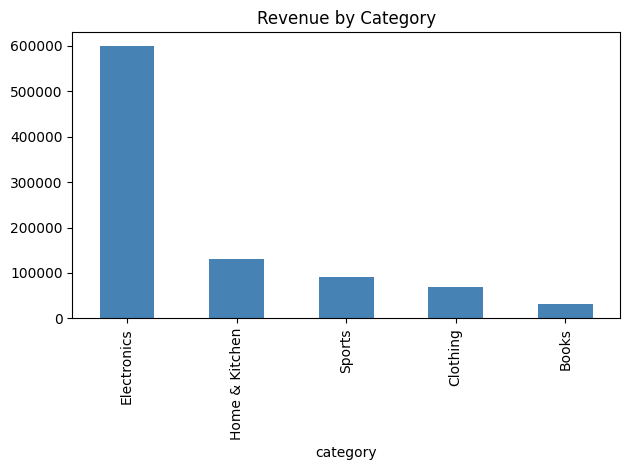

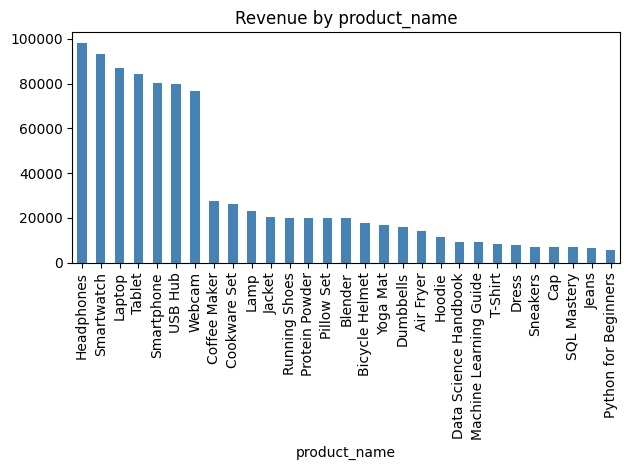

In [6]:

# --- Q1: Revenue by Category and product
cat_rev1 = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)
cat_rev2 = df.groupby('product_name')['total_amount'].sum().sort_values(ascending=False)
# Create the 'charts' directory if it doesn't exist
charts_dir = 'charts'
if not os.path.exists(charts_dir):
    os.makedirs(charts_dir)

cat_rev1.plot(kind='bar', title='Revenue by Category', color='steelblue')
plt.tight_layout(); plt.savefig(os.path.join(charts_dir, 'revenue_by_category.png')); plt.show()

cat_rev2.plot(kind='bar', title='Revenue by product_name', color='steelblue')
plt.tight_layout(); plt.savefig(os.path.join(charts_dir, 'revenue_by_product_name.png')); plt.show()

QUESTION 2: PAISES QUE GENERAN LAS MAYORES VENTAS
RTA: España y Brazil

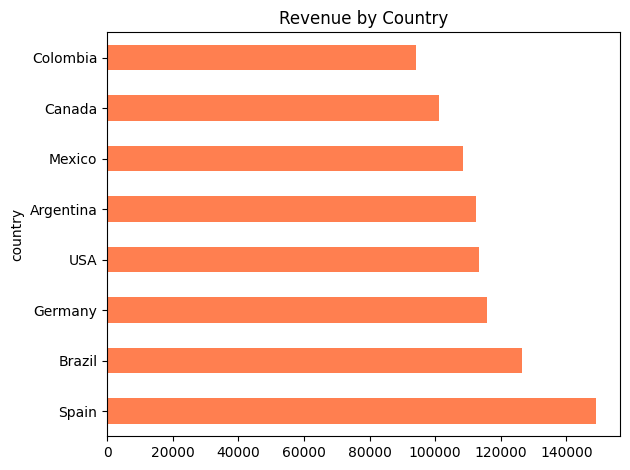

In [7]:
# --- Q2: Revenue by Country ---
country_rev = df.groupby('country')['total_amount'].sum().sort_values(ascending=False)
country_rev.plot(kind='barh', title='Revenue by Country', color='coral')
plt.tight_layout(); plt.savefig('charts/revenue_by_country.png'); plt.show()


QUESTION 3: TENDENCIA DE GANANCIAS MENSUALES EN LOS ULTIMOS 2 AÑOS

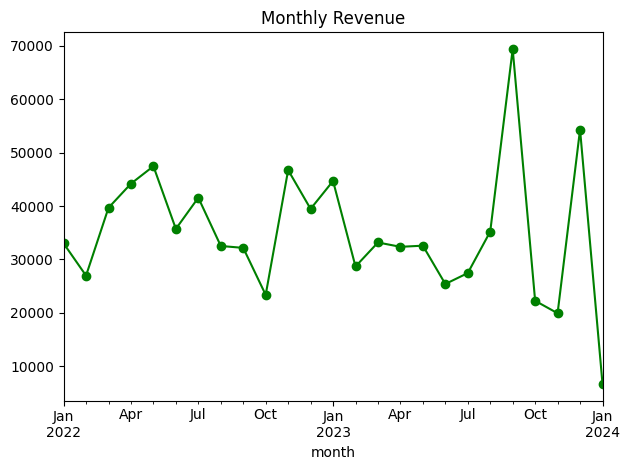

In [8]:
# --- Q3: Monthly Revenue Trend ---
monthly = df.groupby('month')['total_amount'].sum()
monthly.plot(kind='line', title='Monthly Revenue', marker='o', color='green')
plt.tight_layout(); plt.savefig('charts/monthly_trend.png'); plt.show()


QUESTION 4: MÉTODOS DE PAGO MÁS USADOS

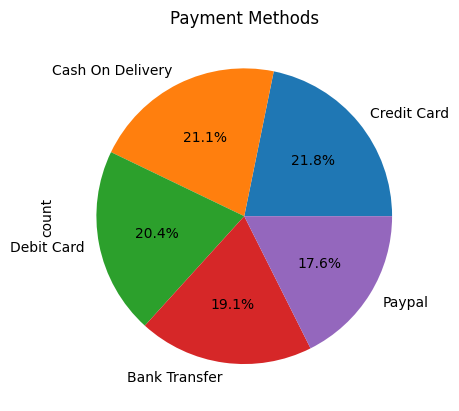

In [9]:
# --- Q4: Payment Methods ---
df['payment_method'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    title='Payment Methods')
plt.savefig('charts/payment_methods.png'); plt.show()


QUESTION 5:CALIFICACIÓN PROMEDIO POR CATEGORIA Y CUALES PRODUCTOS TIENEN LA PEOR CALIFICACIÓN?

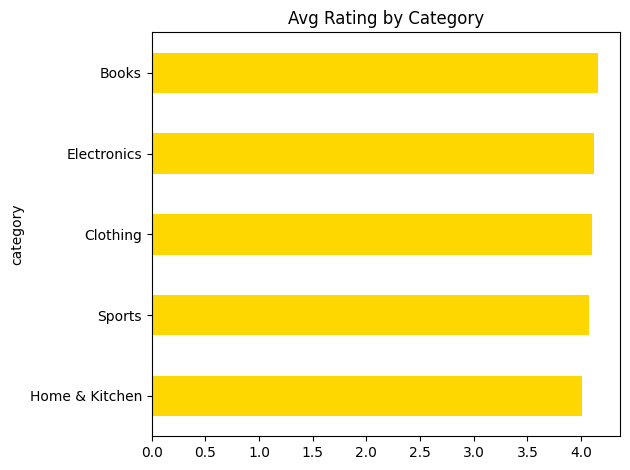

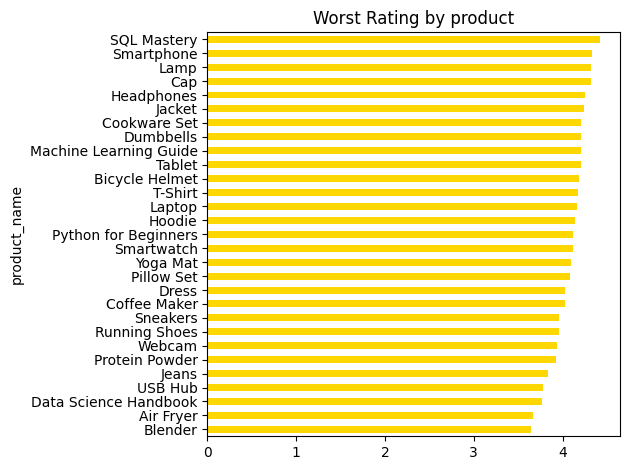

In [12]:
# --- Q5: Average Rating by Category ---
avg_rating = df.groupby('category')['rating'].mean().sort_values()
avg_rating.plot(kind='barh', title='Avg Rating by Category', color='gold')
plt.tight_layout(); plt.savefig('charts/avg_rating.png'); plt.show()

worst_rating = df.groupby('product_name')['rating'].mean().sort_values()
worst_rating.plot(kind='barh', title='Worst Rating by product', color='gold')
plt.tight_layout(); plt.savefig('charts/worst_rating.png'); plt.show()




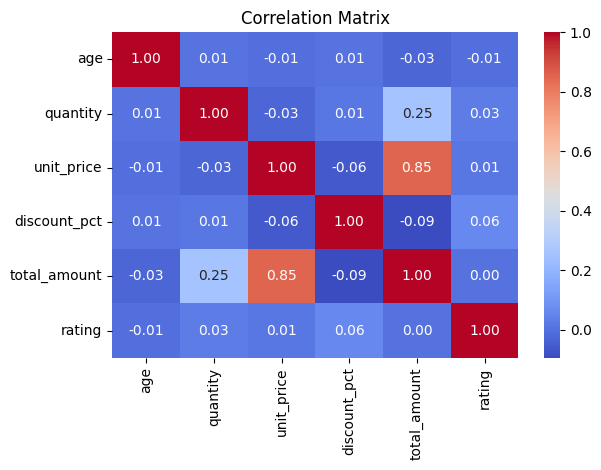

In [13]:

# --- Correlation Heatmap ---
num_cols = ['age','quantity','unit_price','discount_pct','total_amount','rating']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout(); plt.savefig('charts/correlation.png'); plt.show()


INSIGHTS:
- La categoría de electronics es la que más se vende y la que menos se vende es la de books
- En los paises que mas se venden es España y Brazil y los que menos Colombia y Canadá
- No hay diferencia significativa en los medios de pago
- Las ventas caen significativamente en SEP-OCT y a inicio de año JAN
- las calificaciones de todas las categorías son en promedio de 4.0
- Los productos con peores calificaciones son los Blender y las Air fryier
- Puede haber una correlación fuerte entre el precio por unidad y la cantidad total de pedido
- Puede haber una correlación no tan fuerte entre la cantidad y la cantidad total pedida